## 7c. Remote At Outer Arms

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
import seaborn as sns
import copy

In [3]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMind, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new

[2025-10-24 11:39:53,515][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[11:39:58][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:39:58][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:39:58][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:39:59][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.changeOfMind_figures.notebook7c import save_remote_animal_figure7c, load_remote_animal_figure7c

In [5]:
# Algorithm
# for each trial:
# select time bins the animal is running outbound at 5 cm/s on home arm
#     for each home arm bins:
#        use 1D position info to find sum across time bins that animal is in that home arm bin
#        sum posterior at all bins within home arm
#

# for each trial:
# select time bins the animal is within center platform, by 2D position
# sum across time bins that animal is in that home arm bin
# sum posterior at all bins within all outer arms

In [6]:
def figure7c(animal,list_of_days,classifier_param_name,encoding_set,params_pre,params_post):
    posterior_arm_pre, arm_position, _ = find_remote_theta_animal_new(
        animal,list_of_days,classifier_param_name,encoding_set,**params_pre)
    posterior_arm_control_pre, _, _ = find_remote_theta_animal_new(
        animal,list_of_days,classifier_param_name,encoding_set,control=True,**params_pre)
    
    posterior_arm_post, arm_position, _ = find_remote_theta_animal_new(
        animal,list_of_days,classifier_param_name,encoding_set,**params_post)
    posterior_arm_control_post, _, _ = find_remote_theta_animal_new(
        animal,list_of_days,classifier_param_name,encoding_set,control=True,**params_post)
    
    success = save_remote_animal_figure7c(animal, list_of_days, encoding_set, classifier_param_name,params_pre,
                                    posterior_arm_pre, posterior_arm_control_pre, arm_position,
                                    posterior_arm_post, posterior_arm_control_post,
                                    )
    return success

### Pre- and post- change of mind

In [24]:
params_pre = {"use_1d": True,
          "use_home": False,
          "use_center": False,
          "use_outer": True,
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":0,
          "segment_only":True,
          "speed_threshold":None,
          "max_flag": 0,}

params_post = {"use_1d": True,
          "use_home": False,
          "use_center": False,
          "use_outer": True,
          "proportion":0.1,
          "delta_t_minus":0,
          "delta_t_plus":2,
          "segment_only":True,
          "speed_threshold":None,
          "max_flag": 0,
          }

In [29]:
animal = "eliot"
list_of_days = ["20221020","20221021"]

encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success = 0
success = figure7c(animal,list_of_days,classifier_param_name,encoding_set,params_pre,params_post)

[11:54:57][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/eliot_triggered_position_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221020_p0.1_tm5_tp0_maxflag0_multiple_CoM0_single_CoM1_first_CoM0_control0.pkl'

In [27]:
animal = 'Lewis'
list_of_days = ['20240109','20240110']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success = 0
success = figure7c(animal,list_of_days,classifier_param_name,encoding_set,params_pre,params_post)

[11:53:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240109_p0.1_tm5_tp0_maxflag0_multiple_CoM0_single_CoM1_first_CoM1_control0.pkl'

In [28]:
animal = "molly"
list_of_days = ["20220415","20220416","20220417","20220418","20220419","20220420"]

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success = 0
success = figure7c(animal,list_of_days,classifier_param_name,encoding_set,params_pre,params_post)

[11:53:36][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220415_p0.1_tm5_tp0_maxflag0_multiple_CoM0_single_CoM1_first_CoM0_control0.pkl'

In [7]:
def plot(posterior_arm_pre, posterior_arm_control_pre, arm_position, ax, list_of_days, labels):
    posterior_arm_pre_np = np.array(posterior_arm_pre).squeeze()
    posterior_arm_control_pre_np = np.array(posterior_arm_control_pre).squeeze()
    
    mean_pre = np.nanmean(posterior_arm_pre_np, axis = 0)
    sd_pre = np.nanstd(posterior_arm_pre_np, axis = 0)
    
    mean_pre_control = np.nanmean(posterior_arm_control_pre_np, axis = 0)
    sd_pre_control = np.nanstd(posterior_arm_control_pre_np, axis = 0)
    
    for posterior_arm_ in posterior_arm_pre_np:
        ax.plot(np.arange(len(posterior_arm_)),posterior_arm_, 'C1', alpha = 0.2, linewidth = 1)
    
    for posterior_arm_ in posterior_arm_control_pre_np:
        ax.plot(np.arange(len(posterior_arm_)),posterior_arm_, 'C0', alpha = 0.2, linewidth = 1)

    # mean trace
    ax.plot(np.arange(len(mean_pre)), mean_pre, linewidth = 3, color = 'C1', zorder = 100, label = labels[0])
    ax.plot(np.arange(len(mean_pre_control)), mean_pre_control, linewidth = 3, color = 'C0', zorder = 99, label = labels[1])

    # shading
    CI_upper = (mean_pre + sd_pre).reshape((-1,1))
    CI_upper = np.min(np.hstack([CI_upper, np.ones_like(CI_upper)]),axis = 1)

    CI_upper_control = ( mean_pre_control + sd_pre_control).reshape((-1,1))
    CI_upper_control = np.min(np.hstack([CI_upper_control, np.ones_like(CI_upper_control)]),axis = 1)
    
    ax.fill_between(np.arange(len(posterior_arm_)), mean_pre - sd_pre, CI_upper,
                    alpha = 0.4, color = 'C1', zorder = 200, label = labels[0])
    ax.fill_between(np.arange(len(posterior_arm_)), mean_pre_control - sd_pre_control, CI_upper_control,
                    alpha = 0.4, color = 'C0', zorder = 200, label = labels[1])

    ax.set_xticks(np.arange(len(posterior_arm_)))
    ax.set_xticklabels([str(int(np.round(p))) for p in np.mean(arm_position, axis = 1)])
    list_of_days_short = [d[4:8] for d in list_of_days]
    ax.set_title(f"{animal}\n{list_of_days_short}\nlocal posterior when the rat is in outer arm")
    ax.set_ylabel("probability")
    ax.set_xlabel("outer arm bins (10 cm)")
    ax.set_ylim([0,1.1])
    ax.legend()

### Load data

In [17]:
animal = "eliot"
list_of_days = ["20221020","20221021"]

encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'

data = load_remote_animal_figure7c(animal, list_of_days, encoding_set, classifier_param_name,
                                   proportion = 0.1, use_1d = 0)

FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/eliot_figure7e_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221020_20221021_p0.1_use1d0.pkl'

In [16]:
animal = "molly"
list_of_days = ["20220415","20220416","20220417","20220418","20220419","20220420"]

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

data = load_remote_animal_figure7c(animal, list_of_days, encoding_set, classifier_param_name,
                                   proportion = 0.1, use_1d = 0)



FileNotFoundError: [Errno 2] No such file or directory: '/stelmo/shijie/change_of_mind_analysis/molly_figure7e_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220415_20220420_p0.1_use1d0.pkl'

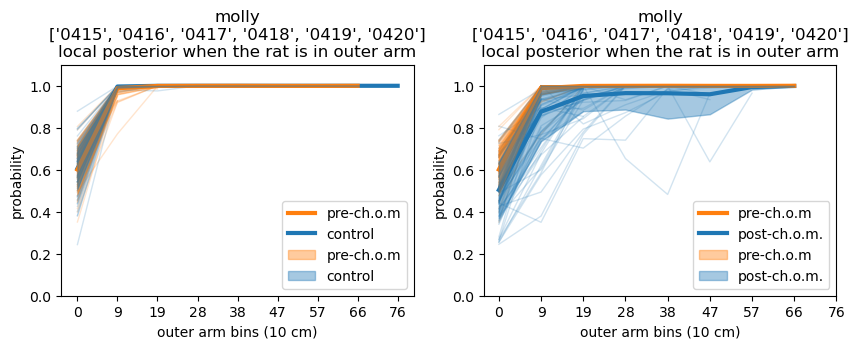

In [127]:
fig, axes = plt.subplots(1,2,figsize = (10,3))
plot(data["posterior_arm_pre"], data["posterior_arm_control_pre"], data["arm_position"], axes[0], list_of_days, ["pre-ch.o.m","control"])
plot(data["posterior_arm_pre"], data["posterior_arm_post"], data["arm_position"], axes[1],list_of_days, ["pre-ch.o.m","post-ch.o.m."])
